Name: Izza Qamar, Sari Ali
Project: INF-201 Deliverable-4

# Alex's Walk Home: Parameter Exploration

This notebook explores how different probability values for **p_kaia** and **p_pentagon** affect Alex's walk home simulation. We run experiments with various parameter combinations and visualize the results to understand their impact.


## 1. Import Required Libraries

In [12]:
import sys
sys.path.insert(0, r'D:\NMBU\semester_1\INF-201\D4_Izza_Sari')

from walk.location import Location
from walk.walker import Walker
from walk.simulation import Simulation
from walk.experiment import Experiment

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd




## 2. Set Up Simulation Parameters

We'll define the base parameters for our experiments and the ranges of probability values to test.

In [14]:
NUM_TRIALS = 1000
SEED = 42

p_values = np.linspace(0, 1, 11)

## 3. Run Simulations with Varying p_kaia

Vary p_kaia (p_pentagon fixed at 0.5)

In [17]:
p_pentagon_fixed = 0.5
results_kaia = []

for p_kaia in p_values:
    p_railway = 1.0 - p_kaia - p_pentagon_fixed
    if p_railway < 0:  # Skip invalid combinations
        continue

    # Create Location object
    loc = Location(p_pentagon=p_pentagon_fixed, p_kaia=p_kaia)
    
    # Create Experiment object
    exp = Experiment(num_simulations=NUM_TRIALS, seed=SEED, location=loc)
    
    # Run simulations
    sim_results = exp.execute()
    
    # Analyze results
    stats = exp.analyze_results(sim_results)
    
    # Append to results list
    results_kaia.append({
        'p_kaia': p_kaia,
        'kaia_pct': stats['destinations'].get('Kaia', 0) / NUM_TRIALS * 100,
        'pentagon_pct': stats['destinations'].get('Pentagon', 0) / NUM_TRIALS * 100,
        'railway_pct': stats['destinations'].get('Railway Station', 0) / NUM_TRIALS * 100,
        'avg_seconds': stats['seconds']['mean'],
        'avg_steps': stats['steps']['mean']
    })

# Convert to DataFrame
df_kaia = pd.DataFrame(results_kaia)

## 4. Run Simulations with Varying p_pentagon

Vary p_pentagon (p_kaia fixed at 0.5)

In [18]:
p_kaia_fixed = 0.5
results_pentagon = []

for p_pentagon in p_values:
    p_railway = 1.0 - p_kaia_fixed - p_pentagon
    if p_railway < 0:
        continue

    # Create Location object
    loc = Location(p_pentagon=p_pentagon, p_kaia=p_kaia_fixed)
    
    # Create Experiment object
    exp = Experiment(num_simulations=NUM_TRIALS, seed=SEED, location=loc)
    
    # Run simulations
    sim_results = exp.execute()
    
    # Analyze results
    stats = exp.analyze_results(sim_results)
    
    # Append to results list
    results_pentagon.append({
        'p_pentagon': p_pentagon,
        'kaia_pct': stats['destinations'].get('Kaia', 0) / NUM_TRIALS * 100,
        'pentagon_pct': stats['destinations'].get('Pentagon', 0) / NUM_TRIALS * 100,
        'railway_pct': stats['destinations'].get('Railway Station', 0) / NUM_TRIALS * 100,
        'avg_seconds': stats['seconds']['mean'],
        'avg_steps': stats['steps']['mean']
    })

# Convert to DataFrame
df_pentagon = pd.DataFrame(results_pentagon)

## 5. Visualize Results:


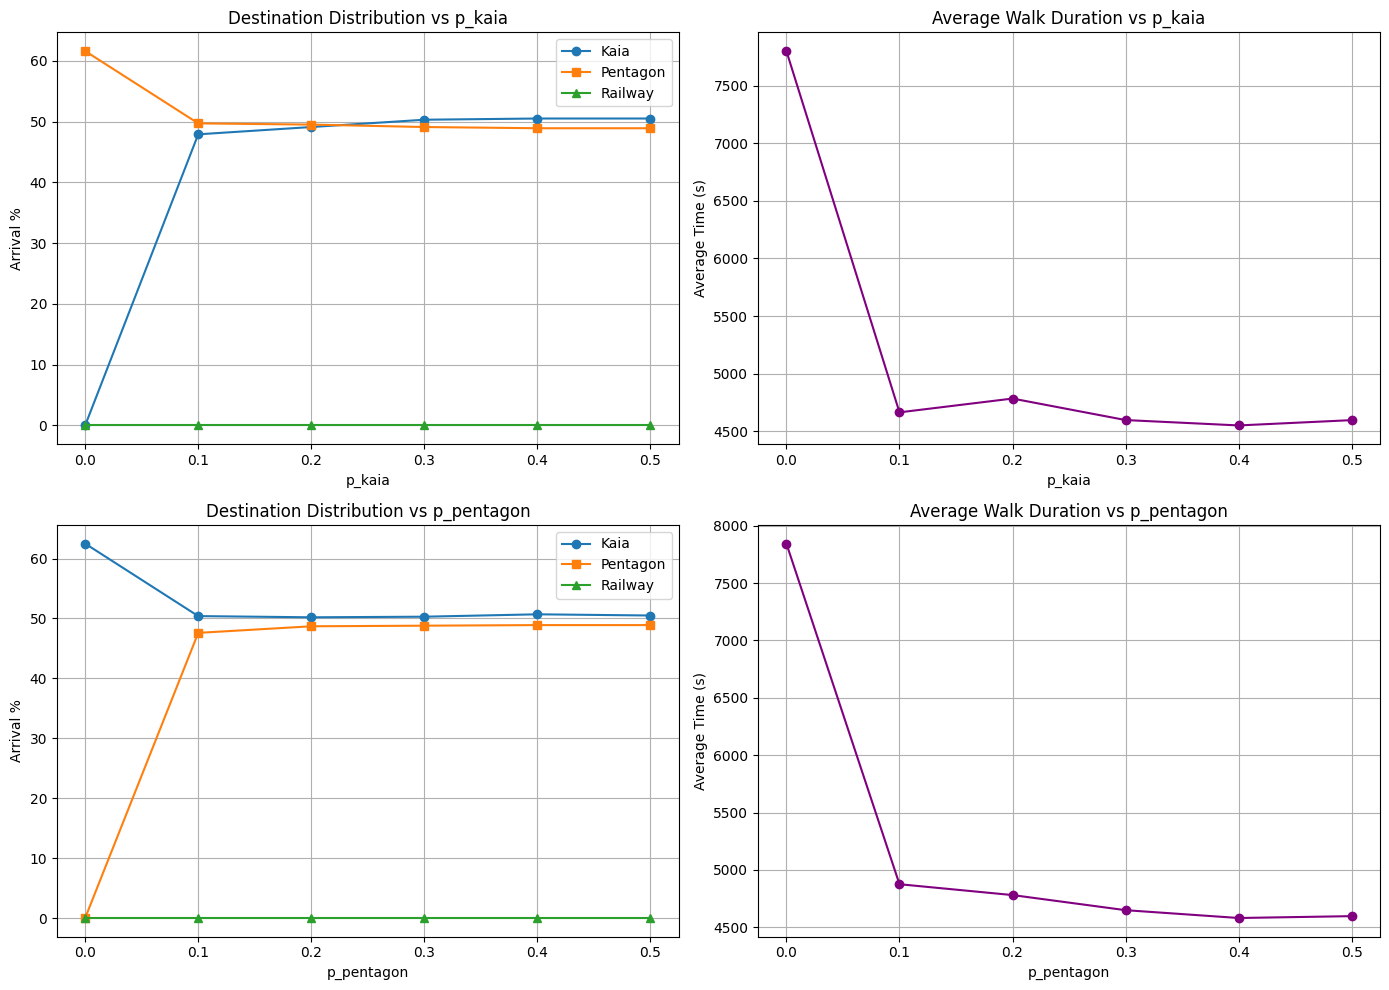

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: Destination % vs p_kaia
ax = axes[0, 0]
ax.plot(df_kaia['p_kaia'], df_kaia['kaia_pct'], marker='o', label='Kaia')
ax.plot(df_kaia['p_kaia'], df_kaia['pentagon_pct'], marker='s', label='Pentagon')
ax.plot(df_kaia['p_kaia'], df_kaia['railway_pct'], marker='^', label='Railway')
ax.set_xlabel('p_kaia')
ax.set_ylabel('Arrival %')
ax.set_title('Destination Distribution vs p_kaia')
ax.legend()
ax.grid(True)

# Top-right: Average walk duration vs p_kaia
ax = axes[0, 1]
ax.plot(df_kaia['p_kaia'], df_kaia['avg_seconds'], marker='o', color='purple')
ax.set_xlabel('p_kaia')
ax.set_ylabel('Average Time (s)')
ax.set_title('Average Walk Duration vs p_kaia')
ax.grid(True)

# Bottom-left: Destination % vs p_pentagon
ax = axes[1, 0]
ax.plot(df_pentagon['p_pentagon'], df_pentagon['kaia_pct'], marker='o', label='Kaia')
ax.plot(df_pentagon['p_pentagon'], df_pentagon['pentagon_pct'], marker='s', label='Pentagon')
ax.plot(df_pentagon['p_pentagon'], df_pentagon['railway_pct'], marker='^', label='Railway')
ax.set_xlabel('p_pentagon')
ax.set_ylabel('Arrival %')
ax.set_title('Destination Distribution vs p_pentagon')
ax.legend()
ax.grid(True)

# Bottom-right: Average walk duration vs p_pentagon
ax = axes[1, 1]
ax.plot(df_pentagon['p_pentagon'], df_pentagon['avg_seconds'], marker='o', color='purple')
ax.set_xlabel('p_pentagon')
ax.set_ylabel('Average Time (s)')
ax.set_title('Average Walk Duration vs p_pentagon')
ax.grid(True)

plt.tight_layout()
plt.show()

## 6. Observations and Conclusions

Based on the visualizations and analysis above, here are the key observations:

### **Impact of p_kaia:**
- Shift in arrivals: As p_kaia increases, the percentage of arrivals at Kaia increases, while Pentagon arrivals decrease proportionally. Railway remains at 0% throughout.

- Stabilization effect: After p_kaia reaches around 0.2–0.3, the distribution between Kaia and Pentagon stabilizes near a 50%–50% split.

- Walk duration drop: The longest walk times occur at p_kaia = 0, and walk duration drops sharply when p_kaia increases to 0.1.
After that, changes become minor

###  **Impact of p_pentagon:**
- Shift in arrivals: Increasing p_pentagon similarly increases arrivals at Pentagon while decreasing arrivals at Kaia. Railway again remains at 0%.

- Rapid transition: At p_pentagon = 0.1, arrivals already shift heavily toward Pentagon, with results stabilizing at higher values.

- Walk duration trend: As with p_kaia, the walk duration is highest when p_pentagon = 0, and drops significantly at p = 0.1.


###  **Walk Duration Insights:**
- Longest walks occur when all walkers default to the same destination (p = 0), meaning more steps occur before the random process reaches a terminal point.

- Shortest walks happen once there is non-zero probability of choosing either Kaia or Pentagon early, causing Alex to reach an endpoint more quickly.

- Stability at higher probabilities: Once p_kaia or p_pentagon exceeds roughly 0.1, average walk durations stabilize with only small fluctuations.


